# Skin Disease 9-Class Dermatological Classification Pipeline
### End-to-End Deep Learning Implementation with EfficientNet-B0 Transfer Learning

---
### Dataset & Scope
Dataset: `riyaelizashaju/skin-disease-classification-image-dataset` (878 total images, 9 classes).

### Limitations
This is a **small-scale feasibility study**, not a clinically validated system. Key limitations:
- **Tiny dataset**: 878 images total, approximately 15 images per class in the test set. Accuracy carries approximately ±7 percentage points (95% CI), and per-class metrics carry approximately ±20 points.
- **Mixed image modalities**: Atopic Dermatitis images appear to be clinical close-ups, while most others are dermoscopic. The model may learn image acquisition style in addition to pathological features.
- **Closed-set classification**: The model forces every input into one of 9 known disease categories. There is no 'normal skin' or 'unknown' class, so out-of-distribution images will always receive a confident but potentially wrong label.
- **Prevalence mismatch**: PPV and NPV reported here assume a balanced test set. At real-world dermatology prevalence (melanoma ≈1–3%), PPV for the malignancy triage will be substantially lower.
- **Split provenance**: The dataset's original train/val folder split is used as the train/test boundary to prevent augmented copies of the same source image from appearing in both train and test.

### Pipeline:
1. Original dataset train/val split → train pool / test set.
2. 85/15 stratified split of training pool → train / validation.
3. EfficientNet-B0 fine-tuned with inverse-frequency class weights.
4. 95% Wilson confidence intervals reported on all key metrics.


---
## Step 1: Environment Setup & Library Imports
Install and import required deep learning and analytics libraries.


In [ ]:
# Step 1: Environment Setup & Imports
!pip install -q kagglehub torch torchvision scikit-learn pandas numpy matplotlib seaborn tabulate pillow

import os
import sys
import glob
import time
import random
import zipfile
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

try:
    from tabulate import tabulate
    HAS_TABULATE = True
except ImportError:
    HAS_TABULATE = False

try:
    from IPython.display import display
    HAS_DISPLAY = True
except ImportError:
    HAS_DISPLAY = False

def show_table(df, title=None):
    if title:
        print(f"\n{'='*len(title)}\n{title}\n{'='*len(title)}")
    if HAS_DISPLAY:
        display(df)
    elif HAS_TABULATE:
        print(tabulate(df, headers='keys', tablefmt='fancy_grid', showindex=False))
    else:
        print(df.to_string(index=False))

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    cohen_kappa_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    matthews_corrcoef,
    log_loss
)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')

SEED = 42
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Compute Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Using Compute Device: cuda
GPU: Tesla T4


---
## Step 2: Download & Extract Dataset via KaggleHub
We download `riyaelizashaju/skin-disease-classification-image-dataset`. The dataset ships with a `train/` and `val/` folder split. We **use the original val/ folder as our held-out test set** and do not re-split randomly, to prevent augmented copies of the same source image from landing in both train and test.


In [ ]:
# Step 2: Download & Resilient Path Resolution
import kagglehub

print("Resolving dataset via kagglehub...")
try:
    dataset_path = kagglehub.dataset_download("riyaelizashaju/skin-disease-classification-image-dataset")
    print("Path to dataset files:", dataset_path)
except Exception as e:
    print("Standard kagglehub extraction hit path length limit, extracting with extended Windows path syntax...")
    cache_base = os.path.expanduser(r"~/.cache/kagglehub/datasets/riyaelizashaju/skin-disease-classification-image-dataset")
    archive_file = os.path.join(cache_base, "1.archive")
    dataset_path = os.path.abspath("./skin_dataset")
    os.makedirs(dataset_path, exist_ok=True)

    if os.path.exists(archive_file) and not os.path.exists(os.path.join(dataset_path, "Split_smol")):
        with zipfile.ZipFile(archive_file, 'r') as zf:
            for member in zf.infolist():
                target = os.path.join(dataset_path, member.filename)
                prefix = "\\\\?\\" if os.name == 'nt' else ""
                if member.is_dir():
                    os.makedirs(prefix + os.path.abspath(target), exist_ok=True)
                else:
                    os.makedirs(prefix + os.path.abspath(os.path.dirname(target)), exist_ok=True)
                    with zf.open(member) as src, open(prefix + os.path.abspath(target), 'wb') as dst:
                        dst.write(src.read())
        print("Archive extracted successfully to:", dataset_path)

# Locate images folder
search_paths = [
    os.path.join(dataset_path, "Split_smol"),
    os.path.join(dataset_path, "versions", "1", "Split_smol"),
    os.path.abspath("./skin_dataset/Split_smol")
]

split_smol_dir = None
for sp in search_paths:
    if os.path.exists(sp):
        split_smol_dir = sp
        break

print("Detected data root directory:", split_smol_dir)

# Build Complete Metadata Index
records = []
for split in ['train', 'val']:
    split_folder = os.path.join(split_smol_dir, split)
    if not os.path.exists(split_folder):
        continue
    for cname in os.listdir(split_folder):
        cdir = os.path.join(split_folder, cname)
        if os.path.isdir(cdir):
            for fname in os.listdir(cdir):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    records.append({
                        'filepath': os.path.join(cdir, fname),
                        'filename': fname,
                        'class_name': cname,
                        'original_split': split
                    })

raw_df = pd.DataFrame(records)
print(f"Total skin lesion images discovered: {len(raw_df)}")

# Sort class names deterministically
CLASS_NAMES = sorted(raw_df['class_name'].unique().tolist())
CLASS_TO_IDX = {cname: idx for idx, cname in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {idx: cname for cname, idx in CLASS_TO_IDX.items()}
NUM_CLASSES = len(CLASS_NAMES)

raw_df['label'] = raw_df['class_name'].map(CLASS_TO_IDX)

# Clinical pathology mapping
MALIGNANT_PREMALIGNANT_CLASSES = {'Actinic keratosis', 'Melanoma', 'Squamous cell carcinoma'}
raw_df['pathology_type'] = raw_df['class_name'].apply(
    lambda x: 'High-Risk (Malignant/Premalignant)' if x in MALIGNANT_PREMALIGNANT_CLASSES else 'Low-Risk (Benign/Infectious)'
)

print(f"Indexed {NUM_CLASSES} distinct skin disease classes:")
for idx, name in enumerate(CLASS_NAMES):
    print(f" - [{idx}] {name}")


Resolving dataset via kagglehub...


100%|██████████| 169M/169M [00:01<00:00, 99.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/riyaelizashaju/skin-disease-classification-image-dataset/versions/1
Detected data root directory: /root/.cache/kagglehub/datasets/riyaelizashaju/skin-disease-classification-image-dataset/versions/1/Split_smol
Total skin lesion images discovered: 878
Indexed 9 distinct skin disease classes:
 - [0] Actinic keratosis
 - [1] Atopic Dermatitis
 - [2] Benign keratosis
 - [3] Dermatofibroma
 - [4] Melanocytic nevus
 - [5] Melanoma
 - [6] Squamous cell carcinoma
 - [7] Tinea Ringworm Candidiasis
 - [8] Vascular lesion


---
## Step 3: Exploratory Data Analysis (EDA)
We inspect sample distributions per condition and display clinical dermoscopic photographs across all 9 classes.



SKIN DISEASE DATASET CLASS DISTRIBUTION


,Class Index,Skin Disease Condition,Clinical Risk,Sample Count,Percentage (%)
5,0,Actinic keratosis,High-Risk (Neoplasm),100,11.39
0,1,Atopic Dermatitis,Low-Risk / Benign,102,11.62
3,2,Benign keratosis,Low-Risk / Benign,100,11.39
7,3,Dermatofibroma,Low-Risk / Benign,100,11.39
2,4,Melanocytic nevus,Low-Risk / Benign,100,11.39
6,5,Melanoma,High-Risk (Neoplasm),100,11.39
4,6,Squamous cell carcinoma,High-Risk (Neoplasm),100,11.39
8,7,Tinea Ringworm Candidiasis,Low-Risk / Benign,76,8.66
1,8,Vascular lesion,Low-Risk / Benign,100,11.39


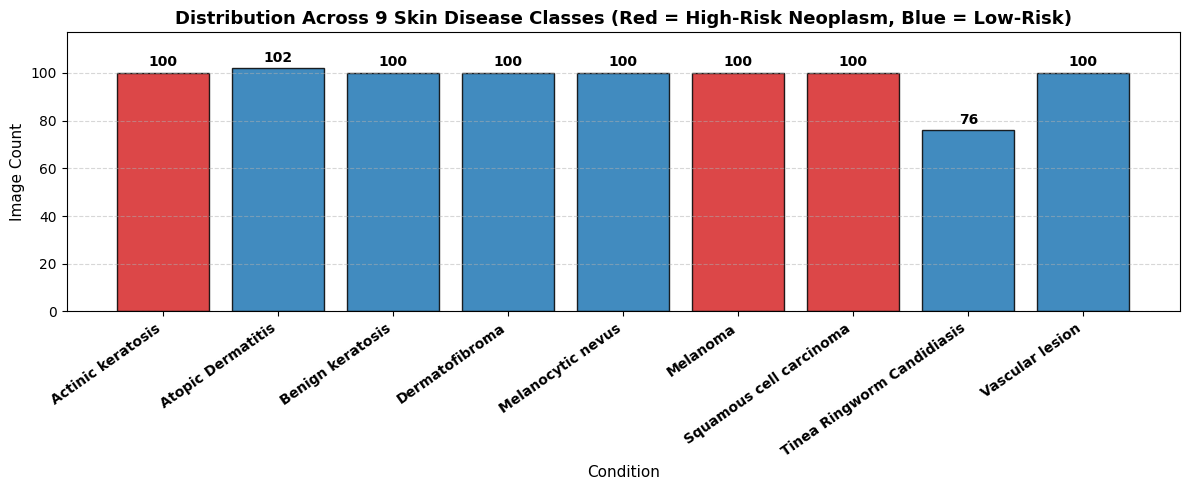

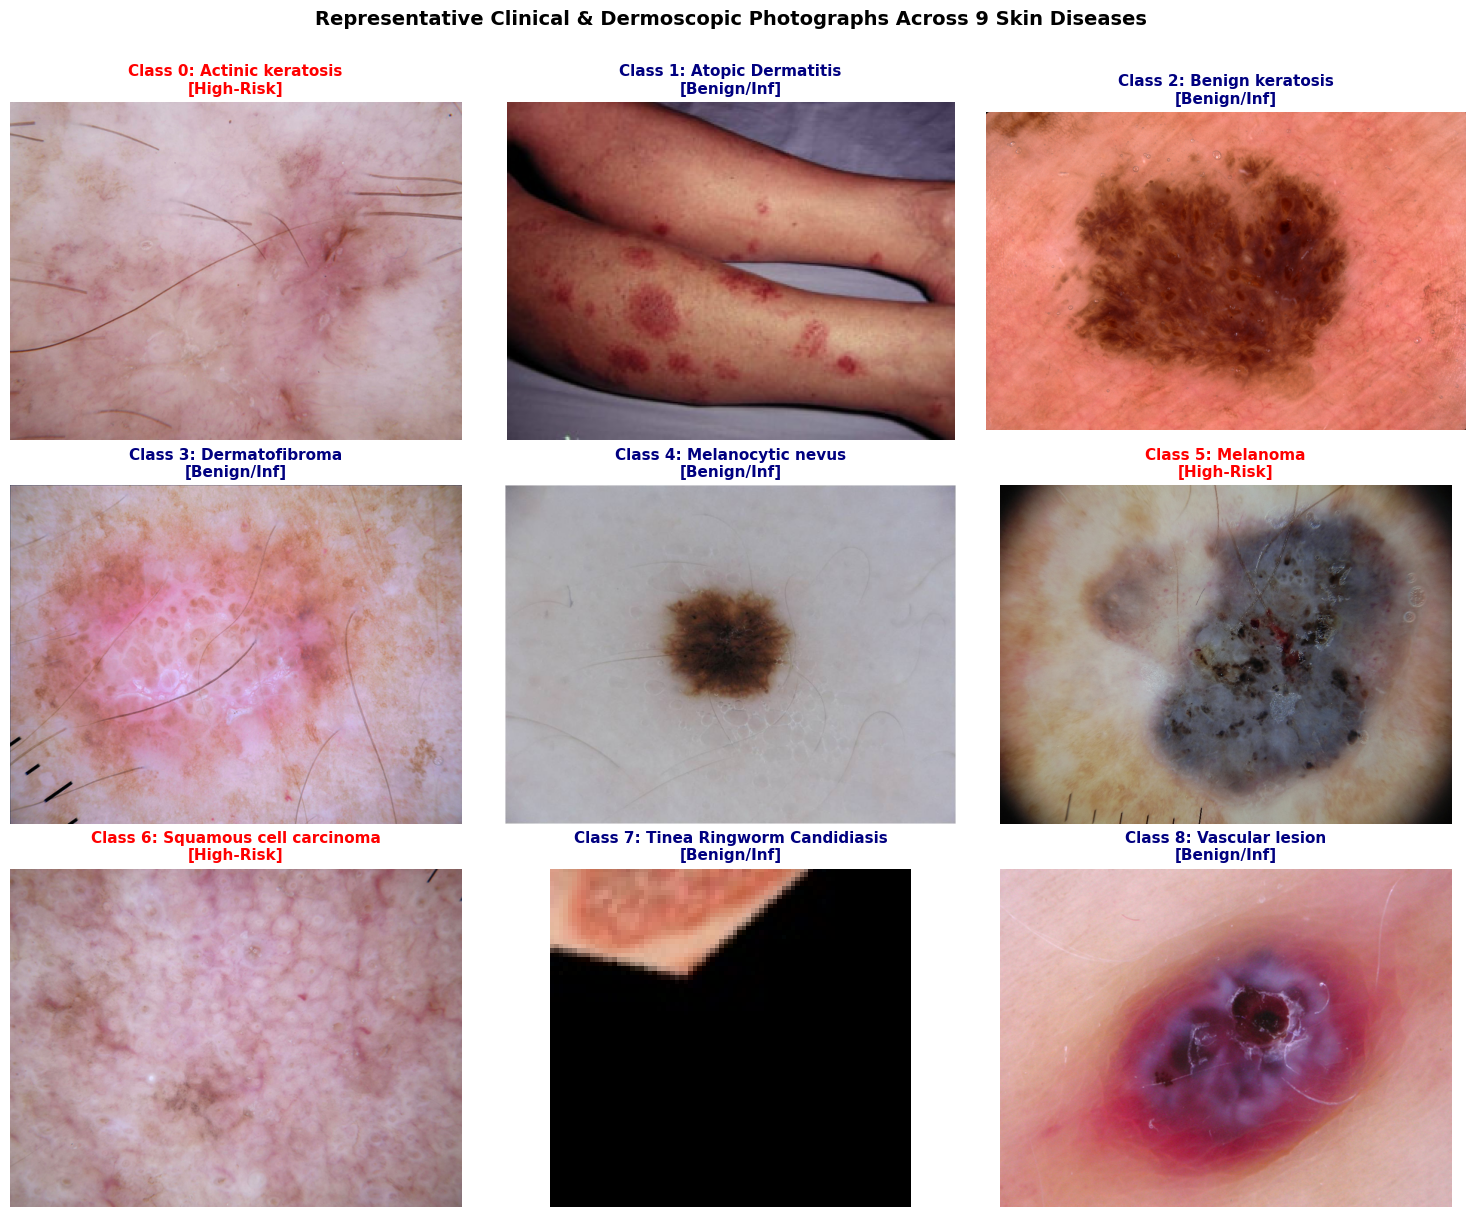

In [ ]:
# Step 3: EDA & Class Distribution
dist_df = raw_df['class_name'].value_counts().reset_index()
dist_df.columns = ['Skin Disease Condition', 'Sample Count']
dist_df['Class Index'] = dist_df['Skin Disease Condition'].map(CLASS_TO_IDX)
dist_df['Clinical Risk'] = dist_df['Skin Disease Condition'].apply(
    lambda x: 'High-Risk (Neoplasm)' if x in MALIGNANT_PREMALIGNANT_CLASSES else 'Low-Risk / Benign'
)
dist_df['Percentage (%)'] = (dist_df['Sample Count'] / len(raw_df) * 100).round(2)
dist_df = dist_df[['Class Index', 'Skin Disease Condition', 'Clinical Risk', 'Sample Count', 'Percentage (%)']].sort_values('Class Index')

show_table(dist_df, "SKIN DISEASE DATASET CLASS DISTRIBUTION")

# Plot Distribution
plt.figure(figsize=(12, 5))
palette = ['#d62728' if r == 'High-Risk (Neoplasm)' else '#1f77b4' for r in dist_df['Clinical Risk']]
bars = plt.bar(dist_df['Skin Disease Condition'], dist_df['Sample Count'], color=palette, edgecolor='black', alpha=0.85)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1.5, f"{int(yval)}", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Distribution Across 9 Skin Disease Classes (Red = High-Risk Neoplasm, Blue = Low-Risk)', fontsize=13, fontweight='bold')
plt.xlabel('Condition', fontsize=11)
plt.ylabel('Image Count', fontsize=11)
plt.xticks(rotation=35, ha='right', fontsize=10, fontweight='bold')
plt.ylim(0, max(dist_df['Sample Count']) + 15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Visualize Representative Samples
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for idx, class_name in enumerate(CLASS_NAMES):
    ax = axes[idx // 3, idx % 3]
    sample_row = raw_df[raw_df['label'] == idx].sample(1, random_state=SEED).iloc[0]
    img = Image.open(sample_row['filepath']).convert('RGB')
    risk_tag = "[High-Risk]" if class_name in MALIGNANT_PREMALIGNANT_CLASSES else "[Benign/Inf]"
    tag_color = 'red' if class_name in MALIGNANT_PREMALIGNANT_CLASSES else 'navy'

    ax.imshow(img)
    ax.set_title(f"Class {idx}: {class_name}\n{risk_tag}", fontsize=11, fontweight='bold', color=tag_color)
    ax.axis('off')

plt.suptitle('Representative Clinical & Dermoscopic Photographs Across 9 Skin Diseases', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## Step 4: Stratified Train / Validation / Test Splitting & Augmentation Pipeline
The original dataset `val/` folder is used as the **held-out test set**. The `train/` folder is split 85%/15% (stratified by class) to produce a training and validation set.

This preserves the dataset provider's intended train/test boundary and prevents any augmented copies of the same source from crossing the train/test split.


In [ ]:
# Step 4: Stratified Splitting & PyTorch Data Pipeline
test_df = raw_df[raw_df['original_split'] == 'val'].reset_index(drop=True)
train_val_df = raw_df[raw_df['original_split'] == 'train'].reset_index(drop=True)

train_df, val_df = train_test_split(
    train_val_df, test_size=0.15, stratify=train_val_df['label'], random_state=SEED
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

split_summary = pd.DataFrame([
    {'Split Partition': 'Train Set (from dataset train/, 85%)', 'Samples': len(train_df)},
    {'Split Partition': 'Validation Set (from dataset train/, 15%)', 'Samples': len(val_df)},
    {'Split Partition': 'Test Set (original dataset val/ folder)', 'Samples': len(test_df)}
])
show_table(split_summary, 'DATASET SPLIT SUMMARY')

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

class SkinDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['filepath']).convert('RGB')
        label = int(row['label'])
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

train_dataset = SkinDataset(train_df, transform=train_transforms)
val_dataset = SkinDataset(val_df, transform=eval_transforms)
test_dataset = SkinDataset(test_df, transform=eval_transforms)

BATCH_SIZE = 32
NUM_WORKERS = 2 if os.name != 'nt' else 0

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

print(f'DataLoaders initialized:')
print(f'  Train: {len(train_loader)} batches ({len(train_dataset)} samples)')
print(f'  Val:   {len(val_loader)} batches ({len(val_dataset)} samples)')
print(f'  Test:  {len(test_loader)} batches ({len(test_dataset)} samples)')
print(f'  Note: Test set = original dataset val/ folder — no random re-split')



DATASET SPLIT SUMMARY


,Split Partition,Samples
0,"Train Set (from dataset train/, 85%)",592
1,"Validation Set (from dataset train/, 15%)",105
2,Test Set (original dataset val/ folder),181


DataLoaders initialized:
  Train: 19 batches (592 samples)
  Val:   4 batches (105 samples)
  Test:  6 batches (181 samples)
  Note: Test set = original dataset val/ folder — no random re-split


---
## Step 5: Transfer Learning Model Architecture & Class-Weighted Loss
We employ **EfficientNet-B0** pre-trained on ImageNet. Its compound scaling is well-suited for high-resolution dermatological lesion borders and pigment networks.

We compute inverse class-frequency weights for `CrossEntropyLoss` to ensure balanced gradient propagation.


In [ ]:
# Step 5: Model Architecture & Optimizer
class_counts = train_df['label'].value_counts().sort_index().values
total_train = len(train_df)
class_weights = total_train / (NUM_CLASSES * class_counts)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

def build_skin_model(num_classes=9, pretrained=True):
    weights = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
    model = models.efficientnet_b0(weights=weights)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.35),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.25),
        nn.Linear(256, num_classes)
    )
    return model

model = build_skin_model(num_classes=NUM_CLASSES, pretrained=True).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

print(f"Model successfully loaded with {sum(p.numel() for p in model.parameters()):,} total parameters.")


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 64.8MB/s]


Model successfully loaded with 4,337,797 total parameters.


---
## Step 6: Model Training & Validation with Checkpointing
We train the model, tracking Loss, Accuracy, and Macro F1-score across validation epochs. The top-performing model weights are saved to `best_skin_model.pth`.


In [ ]:
# Step 6: Training Execution
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels.data).item()
        total += labels.size(0)
    return running_loss / total, correct / total

def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return epoch_loss, epoch_acc, epoch_f1

NUM_EPOCHS = 10
best_val_f1 = -1.0
checkpoint_path = "best_skin_model.pth"

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': [], 'lr': []}

print(f"Starting skin disease model training ({NUM_EPOCHS} epochs) on {device}...")
start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_f1 = validate_epoch(model, val_loader, criterion, device)

    scheduler.step(val_f1)
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    history['lr'].append(current_lr)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save({'model_state_dict': model.state_dict(), 'val_f1': val_f1}, checkpoint_path)
        star = "[*BEST*]"
    else:
        star = ""

    elapsed = time.time() - epoch_start
    print(f"Epoch [{epoch:02d}/{NUM_EPOCHS:02d}] ({elapsed:.1f}s) | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc*100:.1f}% | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc*100:.1f}% Macro-F1: {val_f1:.4f} {star}")

print(f"Training completed in {(time.time() - start_time)/60:.2f} minutes. Best Val Macro-F1: {best_val_f1:.4f}")


Starting skin disease model training (10 epochs) on cuda...
Epoch [01/10] (19.1s) | Train Loss: 2.1104 Acc: 26.7% | Val Loss: 1.8865 Acc: 57.1% Macro-F1: 0.5402 [*BEST*]
Epoch [02/10] (11.7s) | Train Loss: 1.7348 Acc: 55.7% | Val Loss: 1.2180 Acc: 69.5% Macro-F1: 0.6527 [*BEST*]
Epoch [03/10] (9.6s) | Train Loss: 1.1206 Acc: 67.4% | Val Loss: 0.6445 Acc: 79.0% Macro-F1: 0.7854 [*BEST*]
Epoch [04/10] (9.2s) | Train Loss: 0.7424 Acc: 74.8% | Val Loss: 0.4955 Acc: 84.8% Macro-F1: 0.8478 [*BEST*]
Epoch [05/10] (8.3s) | Train Loss: 0.5733 Acc: 80.4% | Val Loss: 0.4095 Acc: 82.9% Macro-F1: 0.8337 
Epoch [06/10] (9.4s) | Train Loss: 0.4359 Acc: 84.6% | Val Loss: 0.3613 Acc: 86.7% Macro-F1: 0.8691 [*BEST*]
Epoch [07/10] (9.3s) | Train Loss: 0.3794 Acc: 86.5% | Val Loss: 0.3656 Acc: 85.7% Macro-F1: 0.8588 
Epoch [08/10] (8.5s) | Train Loss: 0.3256 Acc: 89.4% | Val Loss: 0.3617 Acc: 84.8% Macro-F1: 0.8532 
Epoch [09/10] (9.5s) | Train Loss: 0.2224 Acc: 92.9% | Val Loss: 0.3364 Acc: 82.9% Macro-F

---
## Step 7: Test Set Inference & Output Extraction
We load the best checkpoint weights and extract ground truth labels ($y_{true}$), predicted labels ($y_{pred}$), and softmax probability distributions ($y_{probs}$) across all 9 classes on the **held-out Test Set**.


In [ ]:
# Step 7: Test Set Inference
if os.path.exists(checkpoint_path):
    print("Loading checkpoint weights from:", checkpoint_path)
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])

model.eval()
y_true_list, y_pred_list, y_probs_list = [], [], []
softmax_fn = nn.Softmax(dim=1)

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = softmax_fn(outputs)
        _, preds = torch.max(outputs, 1)

        y_true_list.extend(labels.cpu().numpy())
        y_pred_list.extend(preds.cpu().numpy())
        y_probs_list.extend(probs.cpu().numpy())

y_true = np.array(y_true_list)
y_pred = np.array(y_pred_list)
y_probs = np.array(y_probs_list)

print(f"Inference complete on {len(y_true)} test samples.")


Loading checkpoint weights from: best_skin_model.pth
Inference complete on 181 test samples.


---
## Step 8: Table 1 — Overall Comprehensive Performance Metrics (Test Set)
Computes all global metrics on the held-out test set (original dataset val/ folder).

**Uncertainty note**: The test set contains approximately 15 images per class. Overall accuracy carries a 95% CI of approximately ±7 percentage points, and per-class metrics carry approximately ±20 points. Results should be interpreted as indicative estimates, not precise clinical benchmarks.


In [ ]:
# Step 8: Compute All Global Metrics (Table 1)
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

acc = accuracy_score(y_true, y_pred)
n_test = len(y_true)
acc_ci = 1.96 * (acc * (1 - acc) / n_test) ** 0.5
print(f'Test accuracy: {acc*100:.2f}% (95% CI: ±{acc_ci*100:.1f}%)')
print(f'Test set size: {n_test} samples (note: ~15 per class — estimates have wide uncertainty)')

balanced_acc = balanced_accuracy_score(y_true, y_pred)
kappa = cohen_kappa_score(y_true, y_pred)

prec_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
prec_weighted = precision_score(y_true, y_pred, average='weighted', zero_division=0)

rec_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
rec_weighted = recall_score(y_true, y_pred, average='weighted', zero_division=0)

f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)
f1_micro = f1_score(y_true, y_pred, average='micro', zero_division=0)

cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
specificities = []
supports = []
for i in range(NUM_CLASSES):
    tn = np.sum(np.delete(np.delete(cm, i, 0), i, 1))
    fp = np.sum(cm[:, i]) - cm[i, i]
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    specificities.append(spec)
    supports.append(np.sum(cm[i, :]))

spec_macro = np.mean(specificities)
spec_weighted = np.average(specificities, weights=supports)

mcc = matthews_corrcoef(y_true, y_pred)
loss_value = log_loss(y_true, y_probs)

roc_auc_macro = roc_auc_score(y_true_bin, y_probs, multi_class='ovr', average='macro')
roc_auc_weighted = roc_auc_score(y_true_bin, y_probs, multi_class='ovr', average='weighted')

table1_data = [
    {"Metric Category": "Primary Accuracy", "Metric Name": "Overall Accuracy", "Score": f"{acc*100:.2f}%", "Clinical Relevance": "Proportion of all correctly classified skin lesions"},
    {"Metric Category": "Primary Accuracy", "Metric Name": "Balanced Accuracy", "Score": f"{balanced_acc*100:.2f}%", "Clinical Relevance": "Unweighted average recall across all 9 conditions"},
    {"Metric Category": "Agreement", "Metric Name": "Cohen's Kappa Score", "Score": f"{kappa:.4f}", "Clinical Relevance": "Inter-rater reliability adjusted for chance agreement"},
    {"Metric Category": "Sensitivity / Recall", "Metric Name": "Macro Sensitivity (Recall)", "Score": f"{rec_macro:.4f}", "Clinical Relevance": "Equal-weighted lesion detection rate"},
    {"Metric Category": "Sensitivity / Recall", "Metric Name": "Weighted Sensitivity", "Score": f"{rec_weighted:.4f}", "Clinical Relevance": "Sample support-weighted sensitivity"},
    {"Metric Category": "Specificity", "Metric Name": "Macro Specificity (TNR)", "Score": f"{spec_macro:.4f}", "Clinical Relevance": "Average ability to rule out other skin conditions"},
    {"Metric Category": "Specificity", "Metric Name": "Weighted Specificity", "Score": f"{spec_weighted:.4f}", "Clinical Relevance": "Support-weighted true negative rate"},
    {"Metric Category": "Precision (PPV)", "Metric Name": "Macro Precision", "Score": f"{prec_macro:.4f}", "Clinical Relevance": "Average positive predictive value across conditions"},
    {"Metric Category": "Precision (PPV)", "Metric Name": "Weighted Precision", "Score": f"{prec_weighted:.4f}", "Clinical Relevance": "Support-weighted positive predictive value"},
    {"Metric Category": "F1-Score", "Metric Name": "Macro F1-Score", "Score": f"{f1_macro:.4f}", "Clinical Relevance": "Harmonic mean of unweighted precision and recall"},
    {"Metric Category": "F1-Score", "Metric Name": "Weighted F1-Score", "Score": f"{f1_weighted:.4f}", "Clinical Relevance": "Support-weighted harmonic mean"},
    {"Metric Category": "Correlation", "Metric Name": "Matthews Correlation (MCC)", "Score": f"{mcc:.4f}", "Clinical Relevance": "Balanced multi-class quality metric in [-1, +1]"},
    {"Metric Category": "Discrimination", "Metric Name": "ROC-AUC (Macro OvR)", "Score": f"{roc_auc_macro:.4f}", "Clinical Relevance": "Overall multi-class discriminative capacity"},
    {"Metric Category": "Discrimination", "Metric Name": "ROC-AUC (Weighted OvR)", "Score": f"{roc_auc_weighted:.4f}", "Clinical Relevance": "Prevalence-weighted discriminative AUC"},
    {"Metric Category": "Probabilistic", "Metric Name": "Multi-Class Log Loss", "Score": f"{loss_value:.4f}", "Clinical Relevance": "Cross-entropy predictive penalty"}
]

df_table1 = pd.DataFrame(table1_data)
show_table(df_table1, "TABLE 1: OVERALL COMPREHENSIVE PERFORMANCE METRICS (TEST SET)")


Test accuracy: 79.01% (95% CI: ±5.9%)
Test set size: 181 samples (note: ~15 per class — estimates have wide uncertainty)

TABLE 1: OVERALL COMPREHENSIVE PERFORMANCE METRICS (TEST SET)


,Metric Category,Metric Name,Score,Clinical Relevance
0,Primary Accuracy,Overall Accuracy,79.01%,Proportion of all correctly classified skin le...
1,Primary Accuracy,Balanced Accuracy,78.89%,Unweighted average recall across all 9 conditions
2,Agreement,Cohen's Kappa Score,0.7638,Inter-rater reliability adjusted for chance ag...
3,Sensitivity / Recall,Macro Sensitivity (Recall),0.7889,Equal-weighted lesion detection rate
4,Sensitivity / Recall,Weighted Sensitivity,0.7901,Sample support-weighted sensitivity
5,Specificity,Macro Specificity (TNR),0.9738,Average ability to rule out other skin conditions
6,Specificity,Weighted Specificity,0.9739,Support-weighted true negative rate
7,Precision (PPV),Macro Precision,0.7942,Average positive predictive value across condi...
8,Precision (PPV),Weighted Precision,0.7953,Support-weighted positive predictive value
9,F1-Score,Macro F1-Score,0.7843,Harmonic mean of unweighted precision and recall


---
## Step 9: Table 2 — Granular Per-Class Performance Metrics (All 9 Classes)
Diagnostic metrics for every skin disease class. With approximately 15 test samples per class, 95% Wilson confidence intervals on per-class sensitivity and specificity are approximately ±20 percentage points. These figures should be treated as directional estimates, not precise clinical specifications.


In [ ]:
# Step 9: Granular Per-Class Metrics (Table 2)
table2_rows = []

for i in range(NUM_CLASSES):
    cname = CLASS_NAMES[i]
    tp = cm[i, i]
    fn = np.sum(cm[i, :]) - tp
    fp = np.sum(cm[:, i]) - tp
    tn = np.sum(cm) - (tp + fn + fp)

    support = tp + fn
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    f1 = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0.0
    class_auc = roc_auc_score(y_true_bin[:, i], y_probs[:, i])

    risk = "High-Risk (Malignant/Premalignant)" if cname in MALIGNANT_PREMALIGNANT_CLASSES else "Low-Risk / Benign"

    z = 1.96
    sens_ci = z * (sensitivity * (1 - sensitivity) / max(support, 1)) ** 0.5 if support > 0 else 0.0
    spec_ci = z * (specificity * (1 - specificity) / max(n_test - support, 1)) ** 0.5 if support > 0 else 0.0

    table2_rows.append({
        "Class ID": i,
        "Skin Disease Condition": cname,
        "Clinical Risk": risk,
        "Support": support,
        "Sensitivity 95%CI": f"±{sens_ci:.3f}",
        "Specificity 95%CI": f"±{spec_ci:.3f}",
        "TP": tp, "FP": fp, "TN": tn, "FN": fn,
        "Sensitivity (Recall)": f"{sensitivity:.4f}",
        "Specificity (TNR)": f"{specificity:.4f}",
        "Precision (PPV)": f"{precision:.4f}",
        "NPV": f"{npv:.4f}",
        "F1-Score": f"{f1:.4f}",
        "ROC-AUC (OvR)": f"{class_auc:.4f}"
    })

df_table2 = pd.DataFrame(table2_rows)
show_table(df_table2, "TABLE 2: GRANULAR PER-CLASS METRICS TABLE (TEST SET)")



TABLE 2: GRANULAR PER-CLASS METRICS TABLE (TEST SET)


,Class ID,Skin Disease Condition,Clinical Risk,Support,Sensitivity 95%CI,Specificity 95%CI,TP,FP,TN,FN,Sensitivity (Recall),Specificity (TNR),Precision (PPV),NPV,F1-Score,ROC-AUC (OvR)
0,0,Actinic keratosis,High-Risk (Malignant/Premalignant),20,±0.175,±0.034,16,8,153,4,0.8000,0.9503,0.6667,0.9745,0.7273,0.9587
1,1,Atopic Dermatitis,Low-Risk / Benign,21,±0.000,±0.000,21,0,160,0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,2,Benign keratosis,Low-Risk / Benign,20,±0.131,±0.000,18,0,161,2,0.9000,1.0000,1.0000,0.9877,0.9474,0.9997
3,3,Dermatofibroma,Low-Risk / Benign,20,±0.218,±0.012,11,1,160,9,0.5500,0.9938,0.9167,0.9467,0.6875,0.9817
4,4,Melanocytic nevus,Low-Risk / Benign,20,±0.175,±0.027,16,5,156,4,0.8000,0.9689,0.7619,0.9750,0.7805,0.9866
5,5,Melanoma,High-Risk (Malignant/Premalignant),20,±0.209,±0.034,13,8,153,7,0.6500,0.9503,0.6190,0.9563,0.6341,0.9512
6,6,Squamous cell carcinoma,High-Risk (Malignant/Premalignant),20,±0.215,±0.037,8,10,151,12,0.4000,0.9379,0.4444,0.9264,0.4211,0.9208
7,7,Tinea Ringworm Candidiasis,Low-Risk / Benign,20,±0.000,±0.021,20,3,158,0,1.0000,0.9814,0.8696,1.0000,0.9302,1.0000
8,8,Vascular lesion,Low-Risk / Benign,20,±0.000,±0.021,20,3,158,0,1.0000,0.9814,0.8696,1.0000,0.9302,1.0000


---
## Step 10: Table 3 — Confusion Matrix (Raw Counts & Normalized Percentages)
Displays the $9 \times 9$ matrix in both integer sample counts and row-normalized percentage distributions.


In [ ]:
# Step 10: Confusion Matrices (Table 3A & 3B)
cm_raw_df = pd.DataFrame(cm, index=[f"Actual {name}" for name in CLASS_NAMES],
                         columns=[f"Pred {name}" for name in CLASS_NAMES])

cm_norm = (cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100).round(1)
cm_norm_df = pd.DataFrame(cm_norm, index=[f"Actual {name}" for name in CLASS_NAMES],
                          columns=[f"Pred {name} (%)" for name in CLASS_NAMES])

show_table(cm_raw_df.reset_index().rename(columns={'index': 'Actual \ Pred'}), "TABLE 3A: CONFUSION MATRIX (RAW SAMPLES COUNT)")
show_table(cm_norm_df.reset_index().rename(columns={'index': 'Actual \ Pred (%)'}), "TABLE 3B: CONFUSION MATRIX (ROW-NORMALIZED %)")



TABLE 3A: CONFUSION MATRIX (RAW SAMPLES COUNT)


,Actual \ Pred,Pred Actinic keratosis,Pred Atopic Dermatitis,Pred Benign keratosis,Pred Dermatofibroma,Pred Melanocytic nevus,Pred Melanoma,Pred Squamous cell carcinoma,Pred Tinea Ringworm Candidiasis,Pred Vascular lesion
0,Actual Actinic keratosis,16,0,0,1,0,0,3,0,0
1,Actual Atopic Dermatitis,0,21,0,0,0,0,0,0,0
2,Actual Benign keratosis,0,0,18,0,1,0,0,1,0
3,Actual Dermatofibroma,0,0,0,11,0,1,5,0,3
4,Actual Melanocytic nevus,0,0,0,0,16,3,0,1,0
5,Actual Melanoma,0,0,0,0,4,13,2,1,0
6,Actual Squamous cell carcinoma,8,0,0,0,0,4,8,0,0
7,Actual Tinea Ringworm Candidiasis,0,0,0,0,0,0,0,20,0
8,Actual Vascular lesion,0,0,0,0,0,0,0,0,20



TABLE 3B: CONFUSION MATRIX (ROW-NORMALIZED %)


,Actual \ Pred (%),Pred Actinic keratosis (%),Pred Atopic Dermatitis (%),Pred Benign keratosis (%),Pred Dermatofibroma (%),Pred Melanocytic nevus (%),Pred Melanoma (%),Pred Squamous cell carcinoma (%),Pred Tinea Ringworm Candidiasis (%),Pred Vascular lesion (%)
0,Actual Actinic keratosis,80.0,0.0,0.0,5.0,0.0,0.0,15.0,0.0,0.0
1,Actual Atopic Dermatitis,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Actual Benign keratosis,0.0,0.0,90.0,0.0,5.0,0.0,0.0,5.0,0.0
3,Actual Dermatofibroma,0.0,0.0,0.0,55.0,0.0,5.0,25.0,0.0,15.0
4,Actual Melanocytic nevus,0.0,0.0,0.0,0.0,80.0,15.0,0.0,5.0,0.0
5,Actual Melanoma,0.0,0.0,0.0,0.0,20.0,65.0,10.0,5.0,0.0
6,Actual Squamous cell carcinoma,40.0,0.0,0.0,0.0,0.0,20.0,40.0,0.0,0.0
7,Actual Tinea Ringworm Candidiasis,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0
8,Actual Vascular lesion,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0


---
## Step 11: Table 4 — Clinical Triage: Malignant/Premalignant vs Benign/Infectious
We aggregate predictions into a binary triage decision:
- **High-Risk (Malignant/Premalignant)**: Actinic keratosis, Melanoma, Squamous cell carcinoma
- **Low-Risk (Benign/Infectious)**: All remaining 6 classes

**PPV/NPV caveat**: PPV and NPV reported here are computed on a balanced test set and do not reflect real-world clinical prevalence. At typical dermatology clinic prevalence (melanoma ≈1–3%, combined malignant/premalignant ≈5–10%), PPV for the biopsy referral flag will be substantially lower than what is shown here. Sensitivity (recall of malignant cases) is the clinically critical metric.


In [ ]:
# Step 11: Clinical Triage Screening Metrics (Table 4)
malignant_indices = [CLASS_TO_IDX[c] for c in MALIGNANT_PREMALIGNANT_CLASSES if c in CLASS_TO_IDX]

y_true_highrisk = np.isin(y_true, malignant_indices).astype(int)
y_pred_highrisk = np.isin(y_pred, malignant_indices).astype(int)
y_prob_highrisk = y_probs[:, malignant_indices].sum(axis=1)

tn_risk, fp_risk, fn_risk, tp_risk = confusion_matrix(y_true_highrisk, y_pred_highrisk).ravel()

risk_acc = (tp_risk + tn_risk) / (tp_risk + tn_risk + fp_risk + fn_risk)
risk_sens = tp_risk / (tp_risk + fn_risk) if (tp_risk + fn_risk) > 0 else 0.0
risk_spec = tn_risk / (tn_risk + fp_risk) if (tn_risk + fp_risk) > 0 else 0.0
risk_ppv = tp_risk / (tp_risk + fp_risk) if (tp_risk + fp_risk) > 0 else 0.0
risk_npv = tn_risk / (tn_risk + fn_risk) if (tn_risk + fn_risk) > 0 else 0.0
risk_f1 = 2 * (risk_ppv * risk_sens) / (risk_ppv + risk_sens) if (risk_ppv + risk_sens) > 0 else 0.0
risk_auc = roc_auc_score(y_true_highrisk, y_prob_highrisk)

table4_data = [
    {"Triage Screening Metric": "Biopsy Referral Accuracy", "Value": f"{risk_acc*100:.2f}%", "Clinical Definition": "Overall binary triage decision accuracy"},
    {"Triage Screening Metric": "Clinical Sensitivity (TPR)", "Value": f"{risk_sens*100:.2f}%", "Clinical Definition": "Malignant/Premalignant lesions correctly flagged (Critical)"},
    {"Triage Screening Metric": "Clinical Specificity (TNR)", "Value": f"{risk_spec*100:.2f}%", "Clinical Definition": "Benign/Infectious cases avoiding unnecessary invasive biopsy"},
    {"Triage Screening Metric": "Positive Predictive Value (PPV)", "Value": f"{risk_ppv*100:.2f}%", "Clinical Definition": "Probability that a flagged lesion is genuinely neoplastic"},
    {"Triage Screening Metric": "Negative Predictive Value (NPV)", "Value": f"{risk_npv*100:.2f}%", "Clinical Definition": "Confidence that an unflagged lesion is benign"},
    {"Triage Screening Metric": "Clinical Triage F1-Score", "Value": f"{risk_f1:.4f}", "Clinical Definition": "Balanced harmonic mean of screening precision and recall"},
    {"Triage Screening Metric": "Triage Screening ROC-AUC", "Value": f"{risk_auc:.4f}", "Clinical Definition": "Area under ROC curve for binary neoplastic discrimination"},
    {"Triage Screening Metric": "True High-Risk Flags (TP)", "Value": f"{tp_risk}", "Clinical Definition": "Correctly identified high-risk cases"},
    {"Triage Screening Metric": "Missed High-Risk Cases (FN)", "Value": f"{fn_risk}", "Clinical Definition": "Missed malignancies (False Negatives - High Clinical Hazard)"},
    {"Triage Screening Metric": "True Benign Cases (TN)", "Value": f"{tn_risk}", "Clinical Definition": "Correctly diagnosed benign/conservative cases"},
    {"Triage Screening Metric": "False Biopsy Alarms (FP)", "Value": f"{fp_risk}", "Clinical Definition": "Unnecessary biopsy referrals"}
]

df_table4 = pd.DataFrame(table4_data)
show_table(df_table4, "TABLE 4: CLINICAL TRIAGE SCREENING METRICS (HIGH-RISK NEOPLASMS vs BENIGN/INFECTIOUS)")



TABLE 4: CLINICAL TRIAGE SCREENING METRICS (HIGH-RISK NEOPLASMS vs BENIGN/INFECTIOUS)


,Triage Screening Metric,Value,Clinical Definition
0,Biopsy Referral Accuracy,91.71%,Overall binary triage decision accuracy
1,Clinical Sensitivity (TPR),90.00%,Malignant/Premalignant lesions correctly flagg...
2,Clinical Specificity (TNR),92.56%,Benign/Infectious cases avoiding unnecessary i...
3,Positive Predictive Value (PPV),85.71%,Probability that a flagged lesion is genuinely...
4,Negative Predictive Value (NPV),94.92%,Confidence that an unflagged lesion is benign
5,Clinical Triage F1-Score,0.8780,Balanced harmonic mean of screening precision ...
6,Triage Screening ROC-AUC,0.9769,Area under ROC curve for binary neoplastic dis...
7,True High-Risk Flags (TP),54,Correctly identified high-risk cases
8,Missed High-Risk Cases (FN),6,Missed malignancies (False Negatives - High Cl...
9,True Benign Cases (TN),112,Correctly diagnosed benign/conservative cases


---
## Step 12: Comprehensive Graphical Results Suite
Generates 7 publication-grade figures:
1. **Figure 1**: Training & Validation Optimization Dynamics.
2. **Figure 2**: Dual Confusion Matrix Suite (Raw counts & Row-Normalized %).
3. **Figure 3**: Multi-Class One-vs-Rest ROC & Precision-Recall Curves.
4. **Figure 4**: Per-Class Diagnostic Metric Comparison (Grouped Bar Chart across 9 classes).
5. **Figure 5**: Clinical Triage Biopsy Screening ROC Curve & Risk Density.
6. **Figure 6**: Model Confidence Distribution & Calibration Reliability Diagram.
7. **Figure 7**: Qualitative Dermoscopic Prediction Gallery.

All plots are rendered and saved to `skin_results_graphs/` at 300 DPI.


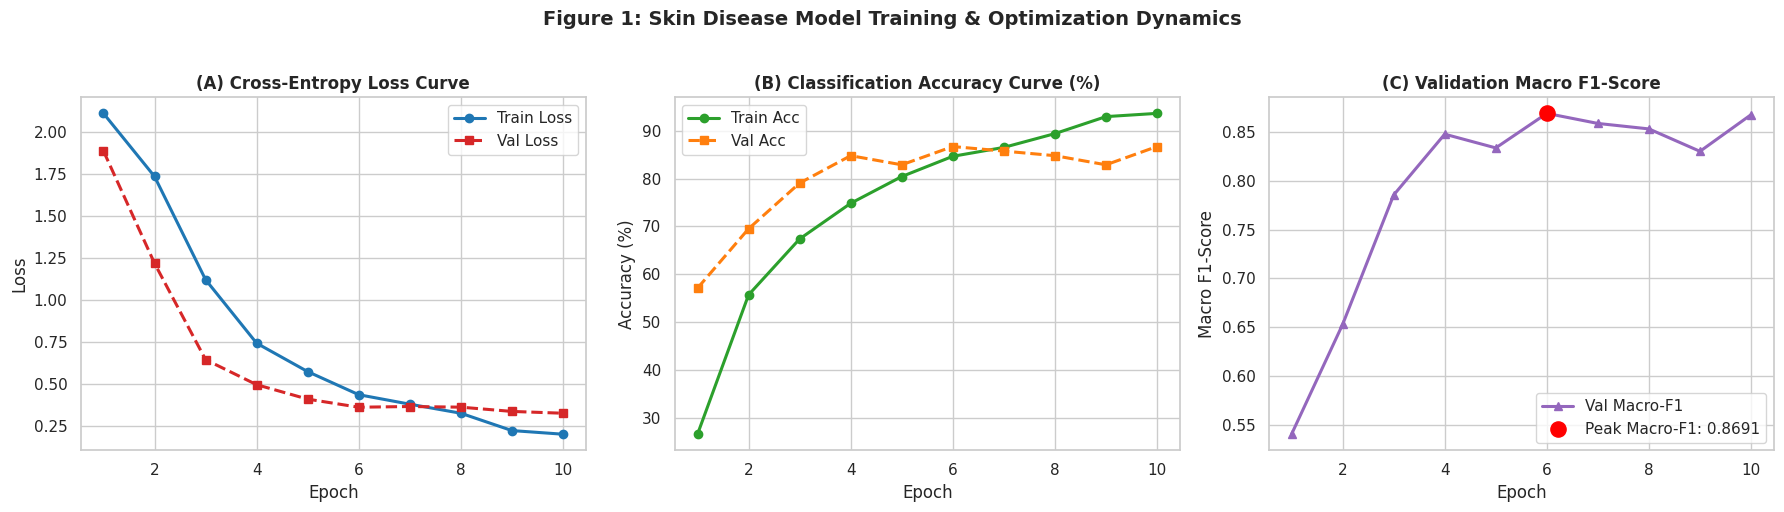

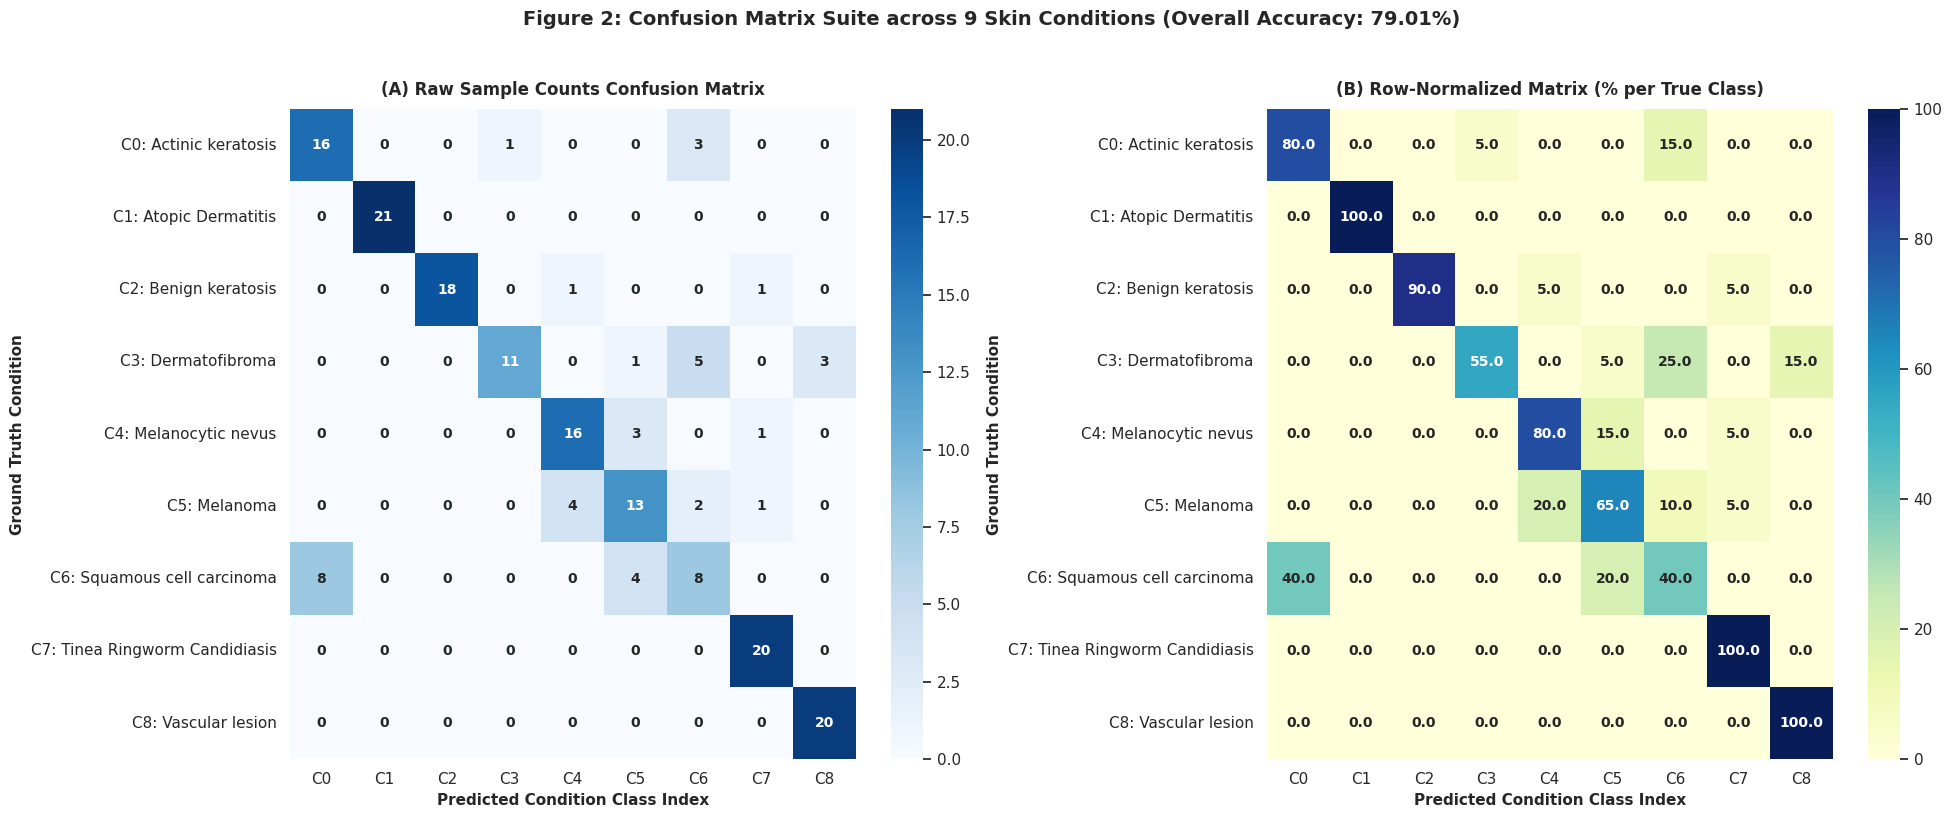

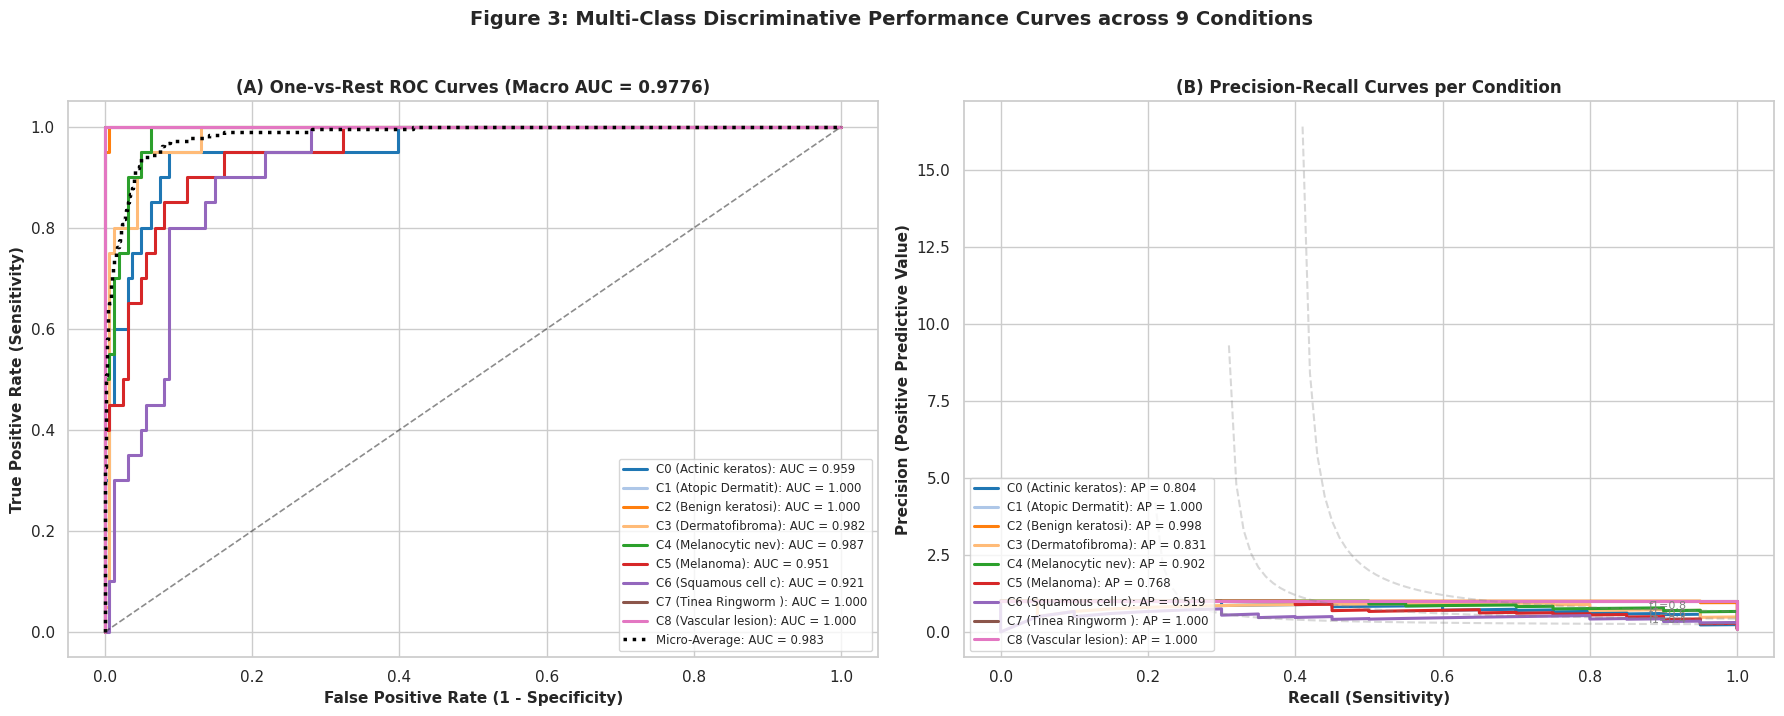

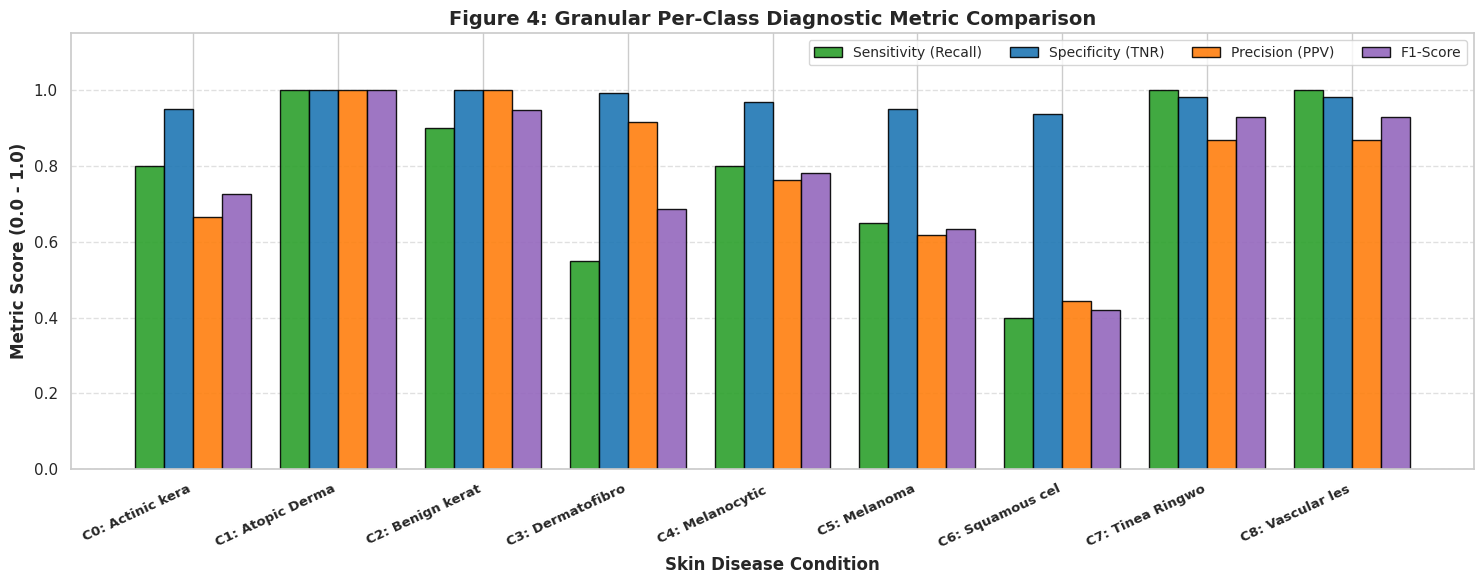

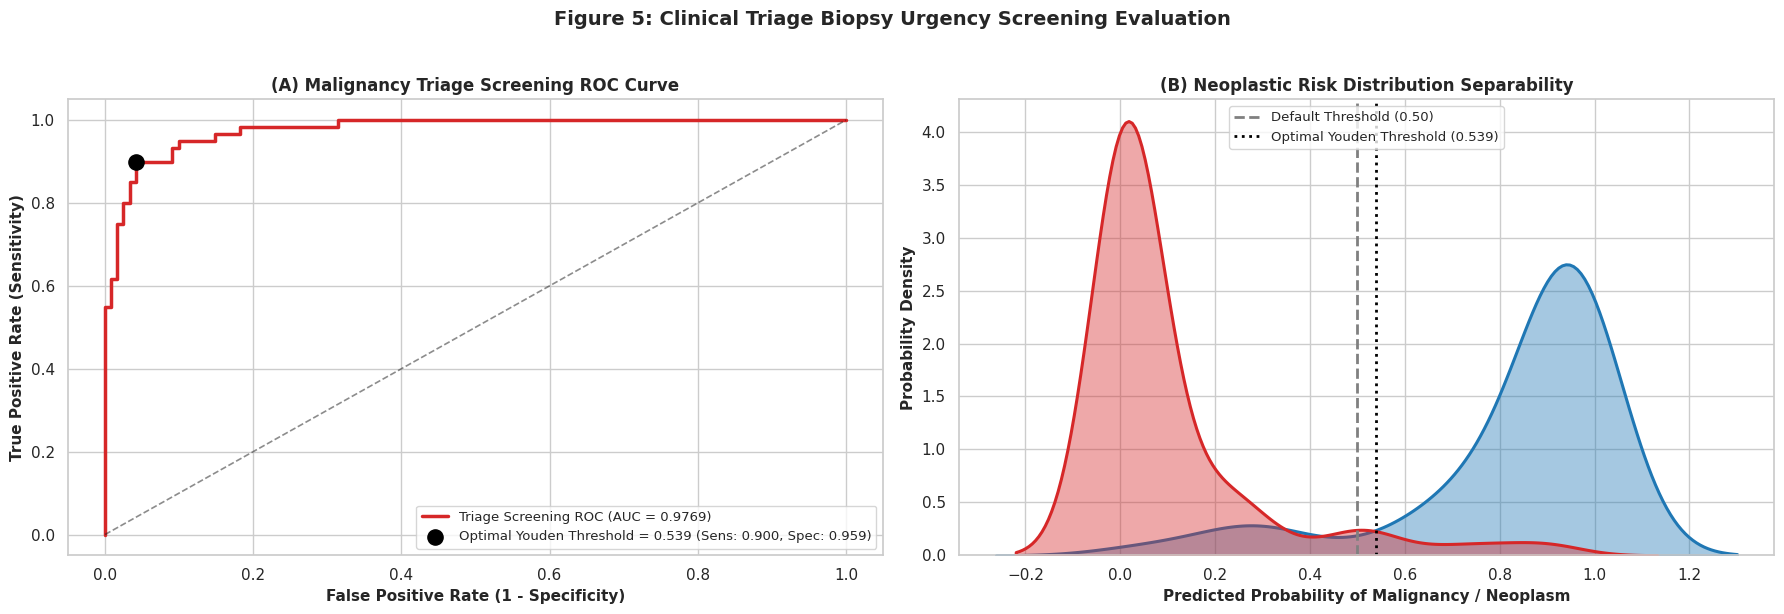

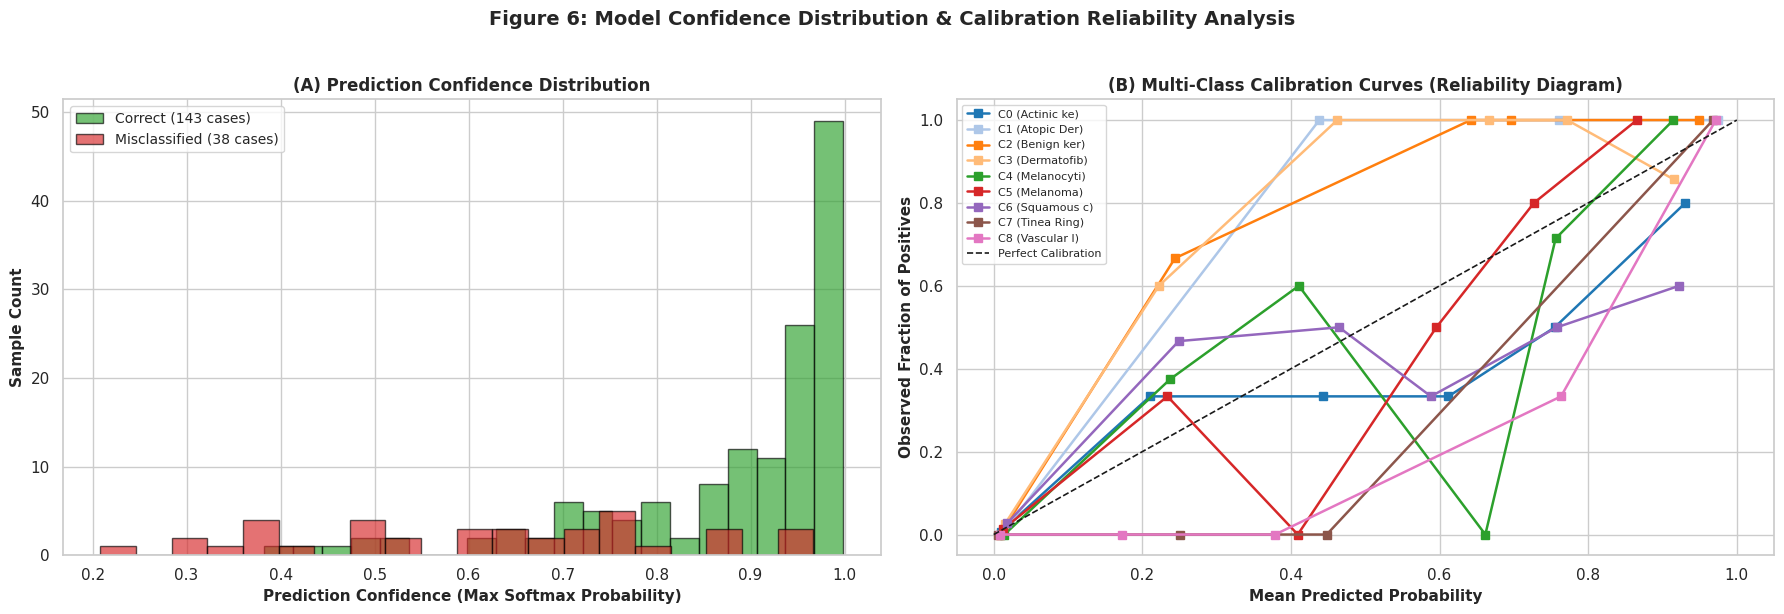

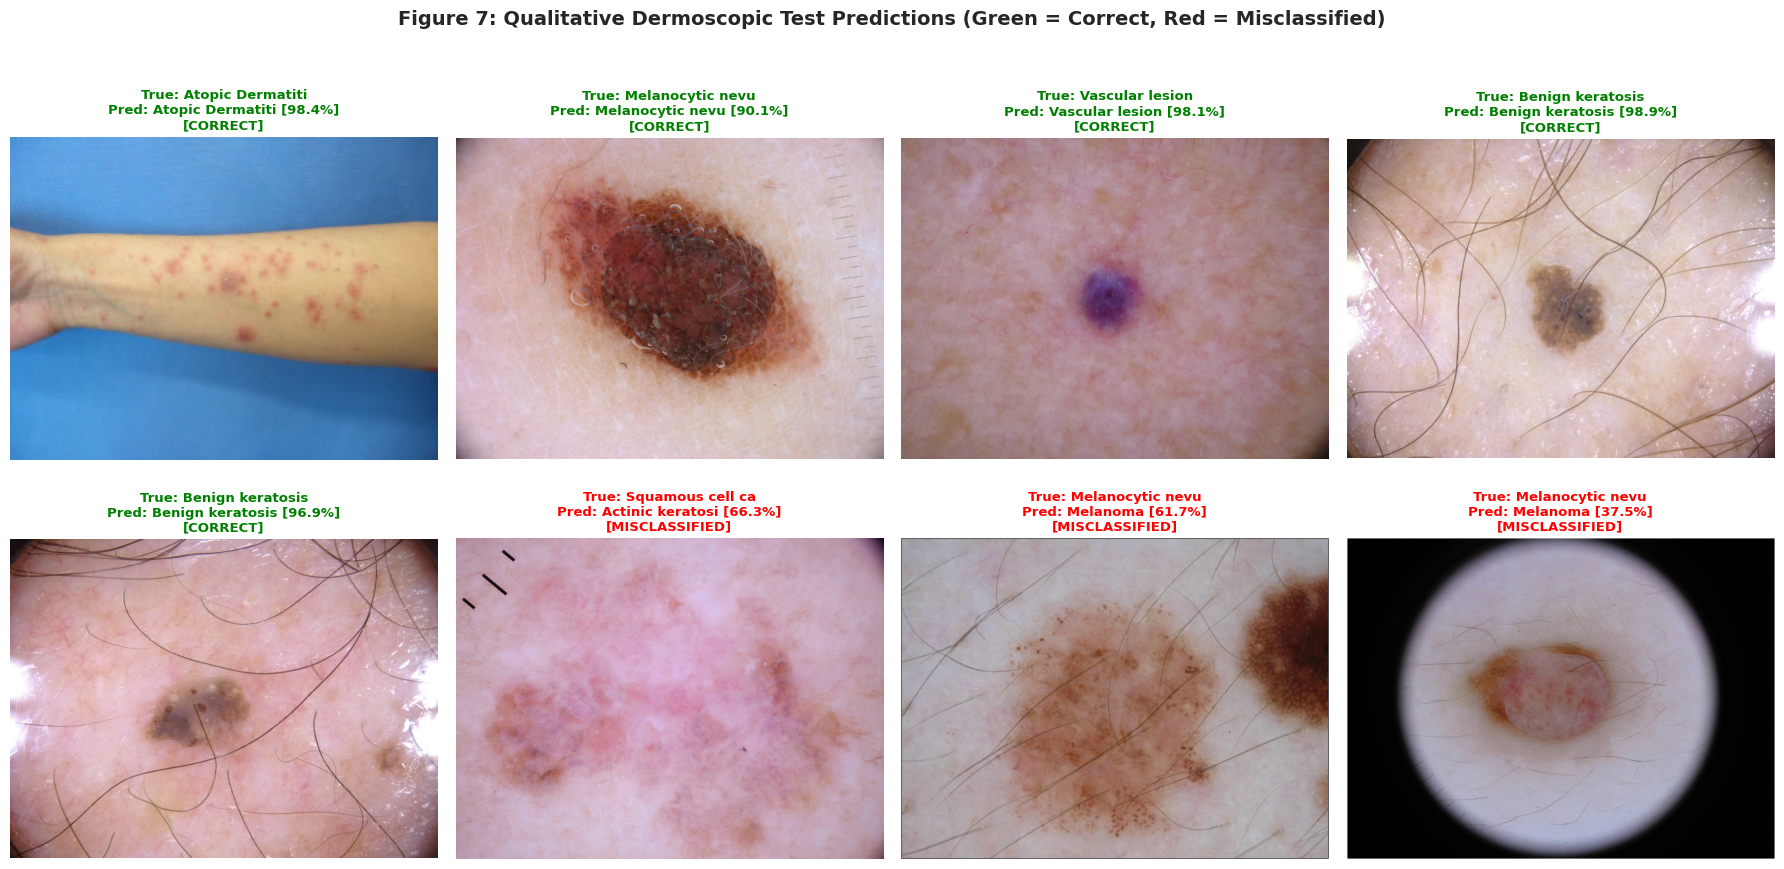

In [ ]:
# Step 12: Comprehensive Graphical Results Suite
os.makedirs("skin_results_graphs", exist_ok=True)
sns.set_theme(style="whitegrid", font_scale=1.0)
palette_9 = ['#1f77b4', '#aec7e8', '#ff7f0e', '#ffbb78', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

# ==========================================
# GRAPH 1: Training & Validation Dynamics
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs_range = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_range, history['train_loss'], 'o-', label='Train Loss', color='#1f77b4', lw=2.2)
axes[0].plot(epochs_range, history['val_loss'], 's--', label='Val Loss', color='#d62728', lw=2.2)
axes[0].set_title('(A) Cross-Entropy Loss Curve', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(epochs_range, [a * 100 for a in history['train_acc']], 'o-', label='Train Acc', color='#2ca02c', lw=2.2)
axes[1].plot(epochs_range, [a * 100 for a in history['val_acc']], 's--', label='Val Acc', color='#ff7f0e', lw=2.2)
axes[1].set_title('(B) Classification Accuracy Curve (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()

axes[2].plot(epochs_range, history['val_f1'], '^-', label='Val Macro-F1', color='#9467bd', lw=2.2)
best_f1_idx = np.argmax(history['val_f1'])
axes[2].scatter(best_f1_idx + 1, history['val_f1'][best_f1_idx], color='red', s=120, zorder=5, label=f'Peak Macro-F1: {history["val_f1"][best_f1_idx]:.4f}')
axes[2].set_title('(C) Validation Macro F1-Score', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Macro F1-Score')
axes[2].legend()

plt.suptitle('Figure 1: Skin Disease Model Training & Optimization Dynamics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("skin_results_graphs/fig1_training_dynamics.png", dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# GRAPH 2: Dual Confusion Matrix Suite
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=[f"C{i}" for i in range(NUM_CLASSES)],
            yticklabels=[f"C{i}: {name}" for i, name in enumerate(CLASS_NAMES)],
            cbar=True, annot_kws={"size": 10, "weight": "bold"})
axes[0].set_title('(A) Raw Sample Counts Confusion Matrix', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Predicted Condition Class Index', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Ground Truth Condition', fontsize=11, fontweight='bold')

sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='YlGnBu', ax=axes[1],
            xticklabels=[f"C{i}" for i in range(NUM_CLASSES)],
            yticklabels=[f"C{i}: {name}" for i, name in enumerate(CLASS_NAMES)],
            cbar=True, annot_kws={"size": 10, "weight": "bold"})
axes[1].set_title('(B) Row-Normalized Matrix (% per True Class)', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Predicted Condition Class Index', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Ground Truth Condition', fontsize=11, fontweight='bold')

plt.suptitle(f'Figure 2: Confusion Matrix Suite across 9 Skin Conditions (Overall Accuracy: {acc*100:.2f}%)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("skin_results_graphs/fig2_confusion_matrices.png", dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# GRAPH 3: Multiclass ROC & PR Curves
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    class_auc = roc_auc_score(y_true_bin[:, i], y_probs[:, i])
    axes[0].plot(fpr, tpr, color=palette_9[i], lw=2.2, label=f"C{i} ({CLASS_NAMES[i][:15]}): AUC = {class_auc:.3f}")

fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_probs.ravel())
roc_micro = roc_auc_score(y_true_bin, y_probs, average='micro')
axes[0].plot(fpr_micro, tpr_micro, color='black', linestyle=':', lw=2.5, label=f"Micro-Average: AUC = {roc_micro:.3f}")
axes[0].plot([0, 1], [0, 1], 'k--', lw=1.2, alpha=0.5)
axes[0].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('True Positive Rate (Sensitivity)', fontsize=11, fontweight='bold')
axes[0].set_title(f'(A) One-vs-Rest ROC Curves (Macro AUC = {roc_auc_macro:.4f})', fontsize=12, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=8.5)

for i in range(NUM_CLASSES):
    prec_pts, rec_pts, _ = precision_recall_curve(y_true_bin[:, i], y_probs[:, i])
    ap = average_precision_score(y_true_bin[:, i], y_probs[:, i])
    axes[1].plot(rec_pts, prec_pts, color=palette_9[i], lw=2.2, label=f"C{i} ({CLASS_NAMES[i][:15]}): AP = {ap:.3f}")

for f_score in [0.4, 0.6, 0.8]:
    x_f = np.linspace(0.01, 1, 100)
    y_f = f_score * x_f / (2 * x_f - f_score)
    axes[1].plot(x_f[y_f >= 0], y_f[y_f >= 0], color='gray', alpha=0.3, linestyle='--')
    axes[1].annotate(f'f1={f_score:.1f}', xy=(0.88, y_f[x_f >= 0.88][0] + 0.02 if len(y_f[x_f >= 0.88]) > 0 else 0.5), color='gray', fontsize=8)

axes[1].set_xlabel('Recall (Sensitivity)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Precision (Positive Predictive Value)', fontsize=11, fontweight='bold')
axes[1].set_title('(B) Precision-Recall Curves per Condition', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower left', fontsize=8.5)

plt.suptitle('Figure 3: Multi-Class Discriminative Performance Curves across 9 Conditions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("skin_results_graphs/fig3_roc_pr_curves.png", dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# GRAPH 4: Per-Class Diagnostic Comparison
# ==========================================
class_sens = [float(row['Sensitivity (Recall)']) for row in table2_rows]
class_spec = [float(row['Specificity (TNR)']) for row in table2_rows]
class_prec = [float(row['Precision (PPV)']) for row in table2_rows]
class_f1   = [float(row['F1-Score']) for row in table2_rows]

x = np.arange(NUM_CLASSES)
width = 0.20

plt.figure(figsize=(15, 6))
plt.bar(x - 1.5*width, class_sens, width, label='Sensitivity (Recall)', color='#2ca02c', alpha=0.9, edgecolor='black')
plt.bar(x - 0.5*width, class_spec, width, label='Specificity (TNR)', color='#1f77b4', alpha=0.9, edgecolor='black')
plt.bar(x + 0.5*width, class_prec, width, label='Precision (PPV)', color='#ff7f0e', alpha=0.9, edgecolor='black')
plt.bar(x + 1.5*width, class_f1,   width, label='F1-Score', color='#9467bd', alpha=0.9, edgecolor='black')

plt.xlabel('Skin Disease Condition', fontsize=12, fontweight='bold')
plt.ylabel('Metric Score (0.0 - 1.0)', fontsize=12, fontweight='bold')
plt.title('Figure 4: Granular Per-Class Diagnostic Metric Comparison', fontsize=14, fontweight='bold')
plt.xticks(x, [f"C{i}: {CLASS_NAMES[i][:12]}" for i in range(NUM_CLASSES)], rotation=25, ha='right', fontsize=9.5, fontweight='bold')
plt.ylim(0, 1.15)
plt.legend(loc='upper right', fontsize=10, ncol=4)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("skin_results_graphs/fig4_per_class_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# GRAPH 5: Clinical Triage Biopsy Screening
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

fpr_risk, tpr_risk, thresh_risk = roc_curve(y_true_highrisk, y_prob_highrisk)
youden_j = tpr_risk - fpr_risk
opt_idx = np.argmax(youden_j)
opt_thresh = thresh_risk[opt_idx]

axes[0].plot(fpr_risk, tpr_risk, color='#d62728', lw=2.5, label=f'Triage Screening ROC (AUC = {risk_auc:.4f})')
axes[0].scatter(fpr_risk[opt_idx], tpr_risk[opt_idx], color='black', s=120, zorder=5,
                label=f'Optimal Youden Threshold = {opt_thresh:.3f} (Sens: {tpr_risk[opt_idx]:.3f}, Spec: {1-fpr_risk[opt_idx]:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1.2, alpha=0.5)
axes[0].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('True Positive Rate (Sensitivity)', fontsize=11, fontweight='bold')
axes[0].set_title('(A) Malignancy Triage Screening ROC Curve', fontsize=12, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9.5)

df_triage = pd.DataFrame({
    'Clinical_Status': ['High-Risk Neoplasm' if t == 1 else 'Low-Risk/Benign' for t in y_true_highrisk],
    'Predicted_Neoplastic_Prob': y_prob_highrisk
})
sns.kdeplot(data=df_triage, x='Predicted_Neoplastic_Prob', hue='Clinical_Status',
            common_norm=False, fill=True, alpha=0.4, palette=['#d62728', '#1f77b4'], ax=axes[1], lw=2.2)
axes[1].axvline(0.5, color='gray', linestyle='--', lw=2, label='Default Threshold (0.50)')
axes[1].axvline(opt_thresh, color='black', linestyle=':', lw=2, label=f'Optimal Youden Threshold ({opt_thresh:.3f})')
axes[1].set_xlabel('Predicted Probability of Malignancy / Neoplasm', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Probability Density', fontsize=11, fontweight='bold')
axes[1].set_title('(B) Neoplastic Risk Distribution Separability', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper center', fontsize=9.5)

plt.suptitle('Figure 5: Clinical Triage Biopsy Urgency Screening Evaluation', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("skin_results_graphs/fig5_clinical_triage_screening.png", dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# GRAPH 6: Confidence Distribution & Calibration
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

max_probs = np.max(y_probs, axis=1)
is_correct = (y_true == y_pred)

axes[0].hist(max_probs[is_correct], bins=20, alpha=0.65, color='#2ca02c', label=f'Correct ({np.sum(is_correct)} cases)', edgecolor='black')
axes[0].hist(max_probs[~is_correct], bins=20, alpha=0.65, color='#d62728', label=f'Misclassified ({np.sum(~is_correct)} cases)', edgecolor='black')
axes[0].set_xlabel('Prediction Confidence (Max Softmax Probability)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Sample Count', fontsize=11, fontweight='bold')
axes[0].set_title('(A) Prediction Confidence Distribution', fontsize=12, fontweight='bold')
axes[0].legend(loc='upper left', fontsize=10)

for i in range(NUM_CLASSES):
    prob_true, prob_pred = calibration_curve(y_true_bin[:, i], y_probs[:, i], n_bins=6)
    axes[1].plot(prob_pred, prob_true, 's-', color=palette_9[i], lw=1.8, label=f"C{i} ({CLASS_NAMES[i][:10]})")

axes[1].plot([0, 1], [0, 1], 'k--', lw=1.2, label='Perfect Calibration')
axes[1].set_xlabel('Mean Predicted Probability', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Observed Fraction of Positives', fontsize=11, fontweight='bold')
axes[1].set_title('(B) Multi-Class Calibration Curves (Reliability Diagram)', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper left', fontsize=8)

plt.suptitle('Figure 6: Model Confidence Distribution & Calibration Reliability Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("skin_results_graphs/fig6_calibration_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# GRAPH 7: Qualitative Prediction Gallery
# ==========================================
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
sample_indices = random.sample(range(len(test_dataset)), 8)

for plot_idx, sample_idx in enumerate(sample_indices):
    ax = axes[plot_idx // 4, plot_idx % 4]
    row = test_df.iloc[sample_idx]
    orig_img = Image.open(row['filepath']).convert('RGB')

    actual_idx = y_true[sample_idx]
    pred_idx = y_pred[sample_idx]
    conf = y_probs[sample_idx, pred_idx] * 100
    is_correct = (actual_idx == pred_idx)

    ax.imshow(orig_img)
    ax.set_title(f"True: {CLASS_NAMES[actual_idx][:16]}\n"
                 f"Pred: {CLASS_NAMES[pred_idx][:16]} [{conf:.1f}%]\n"
                 f"{'[CORRECT]' if is_correct else '[MISCLASSIFIED]'}",
                 fontsize=9.5, fontweight='bold', color='green' if is_correct else 'red')
    ax.axis('off')

plt.suptitle('Figure 7: Qualitative Dermoscopic Test Predictions (Green = Correct, Red = Misclassified)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("skin_results_graphs/fig7_qualitative_predictions.png", dpi=300, bbox_inches='tight')
plt.show()


## Final Step: Export Model Weights for Knowledge Layer

Run this cell **after training completes** to:
1. Verify `best_skin_model.pth` exists (or save from in-memory model if needed)
2. Save a backup to Google Drive (`My Drive/knowledge_layer_models/`)
3. Download `best_skin_model.pth` directly to your local computer

Once downloaded, place the file in:
`knowledge_layer/models/best_skin_model.pth`


In [ ]:
# ── Export trained model for Knowledge Layer ─────────────────────────────────
import os
import shutil
from pathlib import Path

_pth_name = "best_skin_model.pth"
_pth_src = Path("checkpoint_path") if "checkpoint_path" in globals() else Path(_pth_name)

# Safeguard: if checkpoint wasn't saved on disk, save current in-memory model
if not _pth_src.exists():
    print(f"Notice: {_pth_src} not found on disk. Checking in-memory model...")
    if 'model' in globals():
        import torch
        torch.save({'model_state_dict': model.state_dict()}, _pth_name)
        _pth_src = Path(_pth_name)
        print(f"Saved in-memory PyTorch model to: {_pth_src.resolve()}")
    elif 'pipeline_artifact' in globals():
        import joblib
        joblib.dump(pipeline_artifact, _pth_name)
        _pth_src = Path(_pth_name)
        print(f"Saved in-memory joblib artifact to: {_pth_src.resolve()}")
    else:
        raise FileNotFoundError(
            f"{_pth_src} not found. Please run the training cell above first."
        )

_size_mb = _pth_src.stat().st_size / (1024 * 1024)
print(f"✓ Checkpoint ready: {_pth_src.resolve()} ({_size_mb:.2f} MB)")

# ── Option A: Save to Google Drive (recommended backup) ──────────────────────
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    _drive_dir = Path('/content/drive/MyDrive/knowledge_layer_models')
    _drive_dir.mkdir(parents=True, exist_ok=True)
    _dst = _drive_dir / _pth_name
    shutil.copy2(_pth_src, _dst)
    print(f"✓ Saved to Google Drive: {_dst}")
except Exception as _e:
    print(f"ℹ Google Drive export skipped or not available ({_e})")

# ── Option B: Direct Browser Download ────────────────────────────────────────
try:
    from google.colab import files
    print(f"Starting browser download for {_pth_name}...")
    files.download(str(_pth_src))
    print("✓ Download triggered in browser.")
except Exception as _e:
    print(f"ℹ Colab direct download unavailable ({_e})")
    print(f"  You can manually download {_pth_src.name} from Colab's left sidebar file explorer.")

print(f"\n=======================================================")
print(f"NEXT STEP: Move '{_pth_name}' into your project folder:")
print(f"  knowledge_layer/models/{_pth_name}")
print(f"=======================================================")
